<a href="https://colab.research.google.com/github/Cypriansaa/Chestxray_CNN/blob/main/chestxray_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Import Libraries
# ==============================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

from google.colab import drive, files


In [ ]:
# ==============================
# 2. Mount Google Drive & Set Path
# ==============================
drive.mount('/content/drive')

# Updated clean path
base_dir = '/content/drive/MyDrive/chestxray/chest_xray'

train_dir = os.path.join(base_dir, 'train')
val_dir   = os.path.join(base_dir, 'val')
test_dir  = os.path.join(base_dir, 'test')

print("Base directory:", base_dir)
print("Train:", train_dir)
print("Val  :", val_dir)
print("Test :", test_dir)

# ==============================


Mounted at /content/drive
Base directory: /content/drive/MyDrive/chestxray/chest_xray
Train: /content/drive/MyDrive/chestxray/chest_xray/train
Val  : /content/drive/MyDrive/chestxray/chest_xray/val
Test : /content/drive/MyDrive/chestxray/chest_xray/test


Found 5220 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


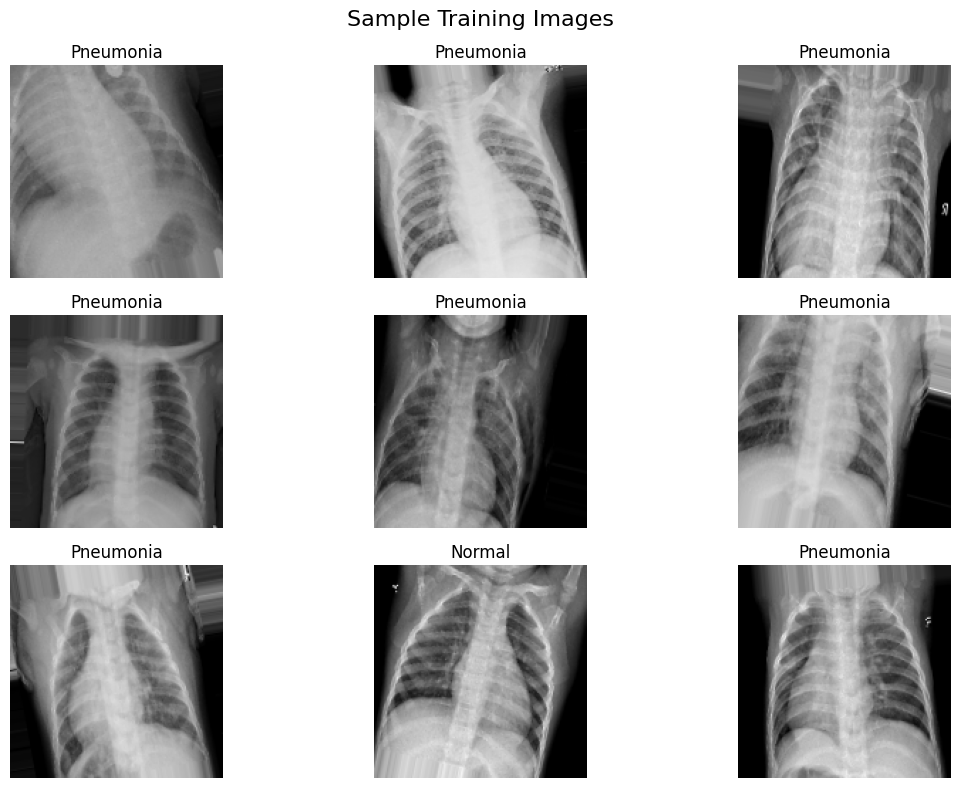

In [ ]:
# 3. Data Generators
# ==============================
IMG_SIZE = 150
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("\nClass indices:", train_generator.class_indices)

# ==============================
# Visualize Sample Images
# ==============================
def plot_sample_images(generator, title="Sample Images"):
    images, labels = next(generator)
    plt.figure(figsize=(12, 8))
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i])
        label = "Pneumonia" if labels[i] == 1 else "Normal"
        plt.title(label)
        plt.axis('off')
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

plot_sample_images(train_generator, "Sample Training Images")

# ==============================


In [ ]:
# 5. Callbacks & Training
# ==============================
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6)
checkpoint = ModelCheckpoint('best_pneumonia_model.h5', monitor='val_accuracy', save_best_only=True)

history = model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

# ==============================


NameError: name 'model' is not defined

In [ ]:
# ==============================
# 4. Build CNN Model
# ==============================
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dropout(0.5),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ==============================

## Training & Evaluation

In [ ]:
# ==============================
# 5. Callbacks & Training
# ==============================
# Define callbacks for training
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6)
checkpoint = ModelCheckpoint('best_pneumonia_model.h5', monitor='val_accuracy', save_best_only=True)

# Train the model
history = model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

# ==============================

## Training & Evaluation Results

In [ ]:
# ==============================
# 6. Learning Curves
# ==============================
def plot_learning_curves(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_learning_curves(history)

# ==============================

In [ ]:
# ==============================
# 7. Evaluate on Test Set
# ==============================
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss    : {test_loss:.4f}")

# ==============================
# Predictions + Confusion Matrix + Classification Report
# ==============================
test_generator.reset()
y_pred_prob = model.predict(test_generator)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_generator.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
# ==============================
# 8. ROC Curve
# ==============================
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
print('Model Architecture Summary:')
model.summary()

In [ ]:
# ==============================
# 6. Learning Curves
# ==============================
def plot_learning_curves(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_learning_curves(history)

# ==============================


In [ ]:
# ==============================
# 7. Evaluate on Test Set
# ==============================
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss    : {test_loss:.4f}")

# ==============================
# Predictions + Confusion Matrix + Classification Report
# ==============================
test_generator.reset()
y_pred_prob = model.predict(test_generator)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_generator.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ==============================


In [ ]:
# 8. ROC Curve
# ==============================
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()



In [ ]:
# 9. Save the Model
# ==============================
model.save('/content/drive/MyDrive/chestxray_pneumonia_cnn.h5')
print("\nModel saved successfully to Google Drive!")


## Prediction Session

In [ ]:
# ============================================================
# Load the saved model for prediction
# ============================================================
model = load_model('/content/drive/MyDrive/chestxray_pneumonia_cnn.h5')

In [ ]:
# ============================================================
# Function to predict on a single image
# ============================================================
def predict_image(model, img_path, img_size=150):
    img = load_img(img_path, target_size=(img_size, img_size))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    prediction = model.predict(img_array, verbose=0)[0][0]

    if prediction > 0.5:
        label = "PNEUMONIA"
        confidence = prediction * 100
    else:
        label = "NORMAL"
        confidence = (1 - prediction) * 100

    return label, confidence


In [ ]:
# ============================================================
# Run the prediction session to upload images and get results
# ============================================================
def prediction_session(model):
    print("\nUpload one or more chest X-ray images...")
    uploaded = files.upload()

    if not uploaded:
        print("No files uploaded.")
        return

    for filename in uploaded.keys():
        label, confidence, img = predict_image(model, filename)

        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.title(f"Prediction: {label}\nConfidence: {confidence:.2f}%", fontsize=14)
        plt.axis('off')
        plt.show()

        print(f"\nFile: {filename}")
        print(f"Result → {label} ({confidence:.2f}% confidence)")
        print("-" * 40)

prediction_session(model)

In [ ]:
from tensorflow.keras.models import load_model
from google.colab import drive, files
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

drive.mount('/content/drive') # Ensure Google Drive is mounted

# 10. PREDICTION SESSION - Predict New Images
# ============================================================

print("\n" + "="*60)
print("PREDICTION SESSION - Upload New Chest X-Ray Images")
print("="*60)

# Load the saved model
model = load_model('/content/drive/MyDrive/chestxray_pneumonia_cnn.h5')

def predict_image(model, img_path, img_size=150):
    img = load_img(img_path, target_size=(img_size, img_size))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    prediction = model.predict(img_array, verbose=0)[0][0]

    if prediction > 0.5:
        label = "PNEUMONIA"
        confidence = prediction * 100
    else:
        label = "NORMAL"
        confidence = (1 - prediction) * 100

    return label, confidence, img

def prediction_session(model):
    print("\nUpload one or more chest X-ray images...")
    uploaded = files.upload()

    if not uploaded:
        print("No files uploaded.")
        return

    for filename in uploaded.keys():
        label, confidence, img = predict_image(model, filename)

        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.title(f"Prediction: {label}\nConfidence: {confidence:.2f}%", fontsize=14)
        plt.axis('off')
        plt.show()

        print(f"\nFile: {filename}")
        print(f"Result → {label} ({confidence:.2f}% confidence)")
        print("-" * 40)

# Run the prediction session
prediction_session(model)

## Project Introduction: Pneumonia Detection using CNN

This project focuses on developing a Convolutional Neural Network (CNN) model to detect pneumonia from chest X-ray images. Pneumonia is a serious lung infection, and early and accurate diagnosis is crucial for effective treatment.

In this work, we've utilized a dataset of chest X-ray images, categorized as 'Normal' or 'Pneumonia', to train and evaluate our deep learning model. The notebook covers the entire machine learning pipeline, including:

*   **Data Preparation:** Loading and augmenting image data to improve model robustness.
*   **Model Architecture:** Designing and implementing a custom CNN model.
*   **Training & Evaluation:** Training the model with appropriate callbacks and evaluating its performance using metrics like accuracy, loss, confusion matrix, and ROC curves.
*   **Prediction Session:** Demonstrating the model's ability to classify new, unseen chest X-ray images as either 'Normal' or 'Pneumonia' with a given confidence score.

The goal is to create a robust and accurate system that can assist medical professionals in the rapid and reliable detection of pneumonia.

In [ ]:
# 2. Mount Google Drive & Set Path
# ==============================
from google.colab import drive
import os

drive.mount('/content/drive')

# Define the base directory where your dataset is stored
base_dir = '/content/drive/MyDrive/chestxray/chest_xray'

# Define paths for training, validation, and test sets
train_dir = os.path.join(base_dir, 'train')
val_dir   = os.path.join(base_dir, 'val')
test_dir  = os.path.join(base_dir, 'test')

print("Base directory:", base_dir)
print("Train set path:", train_dir)
print("Validation set path:", val_dir)
print("Test set path:", test_dir)

This next snippet demonstrates how you create data generators, which are essential for feeding image data into your CNN model. It includes data augmentation techniques to make your model more robust.

In [ ]:
# 3. Data Generators
# ==============================
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

IMG_SIZE = 150  # All images will be resized to 150x150 pixels
BATCH_SIZE = 32 # Number of images processed in one go

# Data augmentation for the training set to prevent overfitting
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixel values to [0, 1]
    rotation_range=15,        # Randomly rotate images by up to 15 degrees
    width_shift_range=0.1,    # Randomly shift images horizontally
    height_shift_range=0.1,   # Randomly shift images vertically
    shear_range=0.1,          # Apply shear transformations
    zoom_range=0.15,          # Randomly zoom in on images
    horizontal_flip=True,     # Randomly flip images horizontally
    fill_mode='nearest'       # Fill in new pixels created by transformations
)

# Only normalization for validation and test sets (no augmentation)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators from directory
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary' # 'binary' because we have two classes (Normal, Pneumonia)
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False # Keep data in order for consistent evaluation
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("\nClass indices:", train_generator.class_indices)

# Function to visualize sample images from the generator
def plot_sample_images(generator, title="Sample Images"):
    images, labels = next(generator) # Get a batch of images and labels
    plt.figure(figsize=(12, 8))
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i])
        label = "Pneumonia" if labels[i] == 1 else "Normal"
        plt.title(label)
        plt.axis('off') # Hide axes for cleaner display
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

plot_sample_images(train_generator, "Sample Training Images")


In [ ]:
# 2. Mount Google Drive & Set Path
# ==============================
from google.colab import drive
import os

drive.mount('/content/drive')

# Define the base directory where your dataset is stored
base_dir = '/content/drive/MyDrive/chestxray/chest_xray'

# Define paths for training, validation, and test sets
train_dir = os.path.join(base_dir, 'train')
val_dir   = os.path.join(base_dir, 'val')
test_dir  = os.path.join(base_dir, 'test')

print("Base directory:", base_dir)
print("Train set path:", train_dir)
print("Validation set path:", val_dir)
print("Test set path:", test_dir)

This next snippet from cell `Nu3w-ugFXNEe` demonstrates how you create `ImageDataGenerator` objects for your training, validation, and test sets. It highlights the use of data augmentation techniques (like rotation, shifting, zooming, and flipping) on the training data to improve model generalization and normalization for all datasets.

In [ ]:
# 3. Data Generators
# ==============================
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

IMG_SIZE = 150  # All images will be resized to 150x150 pixels
BATCH_SIZE = 32 # Number of images processed in one go

# Data augmentation for the training set to prevent overfitting
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixel values to [0, 1]
    rotation_range=15,        # Randomly rotate images by up to 15 degrees
    width_shift_range=0.1,    # Randomly shift images horizontally
    height_shift_range=0.1,   # Randomly shift images vertically
    shear_range=0.1,          # Apply shear transformations
    zoom_range=0.15,          # Randomly zoom in on images
    horizontal_flip=True,     # Randomly flip images horizontally
    fill_mode='nearest'       # Fill in new pixels created by transformations
)

# Only normalization for validation and test sets (no augmentation)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators from directory
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary' # 'binary' because we have two classes (Normal, Pneumonia)
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False # Keep data in order for consistent evaluation
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("\nClass indices:", train_generator.class_indices)

# Function to visualize sample images from the generator
def plot_sample_images(generator, title="Sample Images"):
    images, labels = next(generator) # Get a batch of images and labels
    plt.figure(figsize=(12, 8))
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i])
        label = "Pneumonia" if labels[i] == 1 else "Normal"
        plt.title(label)
        plt.axis('off') # Hide axes for cleaner display
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

plot_sample_images(train_generator, "Sample Training Images")

In [ ]:
# 2. Mount Google Drive & Set Path
# ==============================
from google.colab import drive
import os

drive.mount('/content/drive')

# Define the base directory where your dataset is stored
base_dir = '/content/drive/MyDrive/chestxray/chest_xray'

# Define paths for training, validation, and test sets
train_dir = os.path.join(base_dir, 'train')
val_dir   = os.path.join(base_dir, 'val')
test_dir  = os.path.join(base_dir, 'test')

This next snippet shows the creation of `ImageDataGenerator` instances, including the data augmentation configuration for the training set and simple rescaling for validation and test sets. This is vital for preparing your images for the CNN model.

In [ ]:
# 3. Data Generators
# ==============================
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 150  # All images will be resized to 150x150 pixels
BATCH_SIZE = 32 # Number of images processed in one go

# Data augmentation for the training set to prevent overfitting
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixel values to [0, 1]
    rotation_range=15,        # Randomly rotate images by up to 15 degrees
    width_shift_range=0.1,    # Randomly shift images horizontally
    height_shift_range=0.1,   # Randomly shift images vertically
    shear_range=0.1,          # Apply shear transformations
    zoom_range=0.15,          # Randomly zoom in on images
    horizontal_flip=True,     # Randomly flip images horizontally
    fill_mode='nearest'       # Fill in new pixels created by transformations
)

# Only normalization for validation and test sets (no augmentation)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators from directory
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary' # 'binary' because we have two classes (Normal, Pneumonia)
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False # Keep data in order for consistent evaluation
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

In [ ]:
# Code for Mounting Google Drive and Defining Dataset Paths
from google.colab import drive
import os

drive.mount('/content/drive')

base_dir = '/content/drive/MyDrive/chestxray/chest_xray'

train_dir = os.path.join(base_dir, 'train')
val_dir   = os.path.join(base_dir, 'val')
test_dir  = os.path.join(base_dir, 'test')

In [ ]:
# Code for Data Generators with Augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 150
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

In [ ]:
# Code snippet to show configured data paths
print("Base directory:", base_dir)
print("Train set path:", train_dir)
print("Validation set path:", val_dir)
print("Test set path:", test_dir)

Next, the code to display the class indices found by the `ImageDataGenerator` and a function to visualize sample images from the training generator:

In [ ]:
# Code snippet to show class indices and plot sample images
import matplotlib.pyplot as plt

print("\nClass indices:", train_generator.class_indices)

# Function to visualize sample images from the generator
def plot_sample_images(generator, title="Sample Images"):
    images, labels = next(generator) # Get a batch of images and labels
    plt.figure(figsize=(12, 8))
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i])
        label = "Pneumonia" if labels[i] == 1 else "Normal"
        plt.title(label)
        plt.axis('off') # Hide axes for cleaner display
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

plot_sample_images(train_generator, "Sample Training Images")